In [1]:
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from pathlib import Path
from tqdm.auto import tqdm
import re
import warnings
warnings.filterwarnings("ignore", category=rasterio.errors.NotGeoreferencedWarning)

_ROOT = Path("/Users/farhanhassan/makeathon-challenge-2026")
AEF_BASE = _ROOT / "data/concept_data/aef-embeddings"
S1_BASE = _ROOT / "data/concept_data/sentinel-1"
OUT_DIR = _ROOT / "data/cleaned/features"
OUT_DIR.mkdir(parents=True, exist_ok=True)

BASELINE_YEAR = 2020
DELTA_YEARS = [2021, 2022, 2023, 2024, 2025]

# Discover all tiles
def get_tile_ids(split="train"):
    aef_dir = AEF_BASE / split
    files = sorted(aef_dir.glob("*.tiff"))
    # Extract tile_id from e.g. "18NWG_6_6_2020.tiff"
    tile_ids = set()
    for f in files:
        parts = f.stem.rsplit("_", 1)  # split off year
        tile_ids.add(parts[0])
    return sorted(tile_ids)

train_tiles = get_tile_ids("train")
test_tiles = get_tile_ids("test")
print(f"Train tiles: {len(train_tiles)} — {train_tiles}")
print(f"Test tiles:  {len(test_tiles)} — {test_tiles}")

Train tiles: 5 — ['18NWG_6_6', '18NWH_1_4', '18NWJ_8_9', '18NWM_9_4', '18NXH_6_8']
Test tiles:  5 — ['18NVJ_1_6', '18NYH_2_1', '33NTE_5_1', '47QMA_6_2', '48PWA_0_6']


## 1. AEF Delta Features — Tile-by-Tile Processing

In [2]:
def compute_aef_features(tile_id, split="train"):
    """
    Compute AEF delta features for one tile. Peak RAM: ~2 × 245 MB = 490 MB.
    
    Returns dict with:
      - 'baseline': (64, H, W) — AEF 2020 embedding
      - 'deltas': {year: (64, H, W)} — AEF_year - AEF_2020
      - 'delta_norms': {year: (H, W)} — L2 norm of delta
      - 'cosine_dist': {year: (H, W)} — 1 - cosine similarity to 2020
      - 'profile': rasterio profile for writing
    """
    aef_dir = AEF_BASE / split
    base_path = aef_dir / f"{tile_id}_{BASELINE_YEAR}.tiff"
    
    with rasterio.open(base_path) as src:
        baseline = src.read().astype(np.float32)  # (64, H, W)
        profile = src.profile.copy()
        
    # Precompute baseline norm for cosine distance
    # Shape: (H, W)
    base_norm = np.linalg.norm(baseline, axis=0)
    base_norm = np.where(base_norm > 0, base_norm, np.nan)
    
    deltas = {}
    delta_norms = {}
    cosine_dists = {}
    
    for year in DELTA_YEARS:
        year_path = aef_dir / f"{tile_id}_{year}.tiff"
        if not year_path.exists():
            print(f"  Warning: {year_path.name} not found, skipping")
            continue
            
        with rasterio.open(year_path) as src:
            emb_year = src.read().astype(np.float32)  # (64, H, W)
        
        # Delta
        delta = emb_year - baseline  # (64, H, W)
        deltas[year] = delta
        
        # Delta L2 norm
        delta_norms[year] = np.linalg.norm(delta, axis=0)  # (H, W)
        
        # Cosine distance: 1 - (A_2020 · A_year) / (|A_2020| * |A_year|)
        year_norm = np.linalg.norm(emb_year, axis=0)
        year_norm = np.where(year_norm > 0, year_norm, np.nan)
        dot = np.sum(baseline * emb_year, axis=0)
        cosine_sim = dot / (base_norm * year_norm)
        cosine_dists[year] = 1.0 - cosine_sim
        
        del emb_year  # free memory
    
    return {
        'baseline': baseline,
        'deltas': deltas,
        'delta_norms': delta_norms,
        'cosine_dists': cosine_dists,
        'profile': profile,
    }

# Quick test on one tile
test_result = compute_aef_features(train_tiles[0])
print(f"Tile: {train_tiles[0]}")
print(f"Baseline shape: {test_result['baseline'].shape}")
print(f"Delta years available: {list(test_result['deltas'].keys())}")
for yr in test_result['delta_norms']:
    dn = test_result['delta_norms'][yr]
    cd = test_result['cosine_dists'][yr]
    valid_dn = dn[np.isfinite(dn)]
    valid_cd = cd[np.isfinite(cd)]
    print(f"  {yr}: delta_norm mean={valid_dn.mean():.4f}, cosine_dist mean={valid_cd.mean():.6f}")

Tile: 18NWG_6_6
Baseline shape: (64, 1004, 998)
Delta years available: [2021, 2022, 2023, 2024, 2025]
  2021: delta_norm mean=0.3335, cosine_dist mean=0.083058
  2022: delta_norm mean=0.5763, cosine_dist mean=0.221932
  2023: delta_norm mean=0.5382, cosine_dist mean=0.208559
  2024: delta_norm mean=0.5889, cosine_dist mean=0.239395
  2025: delta_norm mean=0.6190, cosine_dist mean=0.264772


## 2. S1 Temporal Features — Before/After Statistics

In [3]:
def compute_s1_features(tile_id, split="train", before_years=(2020, 2021), after_years=(2023, 2024, 2025)):
    """
    Compute S1 temporal change features for one tile using descending orbit.
    
    Returns dict with:
      - 'before_mean', 'before_std': (H, W) — dB stats for before period
      - 'after_mean', 'after_std': (H, W) — dB stats for after period
      - 'change_mean': (H, W) — after_mean - before_mean
      - 'change_ratio': (H, W) — after_mean / before_mean
      - 's1_profile': rasterio profile
    """
    s1_dir = S1_BASE / split / f"{tile_id}__s1_rtc"
    if not s1_dir.exists():
        print(f"  Warning: S1 dir not found for {tile_id}")
        return None
    
    # Collect files by period, prefer descending orbit
    def get_period_files(years):
        files = []
        for f in sorted(s1_dir.glob("*.tif")):
            m = re.match(r".+__s1_rtc_(\d{4})_(\d{1,2})_(ascending|descending)\.tif", f.name)
            if m and int(m.group(1)) in years:
                orbit = m.group(3)
                # Prefer descending, but take ascending if no descending available
                files.append((f, int(m.group(1)), int(m.group(2)), orbit))
        
        # Filter: keep descending where available, else ascending
        by_month = {}
        for f, yr, mo, orb in files:
            key = (yr, mo)
            if key not in by_month or orb == "descending":
                by_month[key] = f
        return list(by_month.values())
    
    before_files = get_period_files(before_years)
    after_files = get_period_files(after_years)
    
    if not before_files or not after_files:
        print(f"  Warning: insufficient S1 files for {tile_id}")
        return None
    
    def read_stack_db(file_list):
        """Read files and return dB stack."""
        stack = []
        for f in file_list:
            with rasterio.open(f) as src:
                data = src.read(1).astype(np.float32)
                profile = src.profile.copy()
            db = np.where(data > 0, 10 * np.log10(data), np.nan)
            stack.append(db)
        return np.array(stack), profile  # (T, H, W)
    
    before_stack, s1_profile = read_stack_db(before_files)
    after_stack, _ = read_stack_db(after_files)
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        before_mean = np.nanmean(before_stack, axis=0)
        before_std = np.nanstd(before_stack, axis=0)
        after_mean = np.nanmean(after_stack, axis=0)
        after_std = np.nanstd(after_stack, axis=0)
    
    change_mean = after_mean - before_mean
    # Ratio (avoid division by zero)
    safe_before = np.where(np.abs(before_mean) > 0.01, before_mean, np.nan)
    change_ratio = after_mean / safe_before
    
    return {
        'before_mean': before_mean,
        'before_std': before_std,
        'after_mean': after_mean,
        'after_std': after_std,
        'change_mean': change_mean,
        'change_ratio': change_ratio,
        's1_profile': s1_profile,
    }

# Quick test
s1_result = compute_s1_features(train_tiles[0])
if s1_result:
    for k, v in s1_result.items():
        if isinstance(v, np.ndarray):
            valid = v[np.isfinite(v)]
            print(f"  {k}: shape={v.shape}, mean={valid.mean():.3f}, std={valid.std():.3f}")

  before_mean: shape=(334, 335), mean=-6.424, std=1.156
  before_std: shape=(334, 335), mean=1.586, std=0.319
  after_mean: shape=(334, 335), mean=-7.243, std=1.362
  after_std: shape=(334, 335), mean=1.649, std=0.286
  change_mean: shape=(334, 335), mean=-0.819, std=1.157
  change_ratio: shape=(334, 335), mean=1.141, std=0.200


## 3. Save Combined Features per Tile

We save each tile's features as a multi-band GeoTIFF. The bands are:
- Bands 1–64: AEF 2020 baseline
- Bands 65–128, 129–192, ...: AEF deltas for 2021–2025
- Then: delta norms (5), cosine distances (5), S1 features (6)

All in the **AEF CRS** (EPSG:4326). S1 features will be reprojected to match.

In [4]:
def save_tile_features(tile_id, split="train"):
    """Compute and save all features for one tile as a multi-band GeoTIFF."""
    
    print(f"\n{'='*60}")
    print(f"Processing: {tile_id} ({split})")
    print(f"{'='*60}")
    
    # 1. AEF features
    print("  Computing AEF delta features...")
    aef = compute_aef_features(tile_id, split)
    H, W = aef['baseline'].shape[1], aef['baseline'].shape[2]
    aef_profile = aef['profile']
    
    # 2. S1 features (reproject to AEF grid)
    print("  Computing S1 temporal features...")
    s1 = compute_s1_features(tile_id, split)
    
    s1_bands_on_aef = {}
    if s1 is not None:
        s1_keys = ['before_mean', 'before_std', 'after_mean', 'after_std', 'change_mean', 'change_ratio']
        for key in s1_keys:
            reprojected = np.full((H, W), np.nan, dtype=np.float32)
            reproject(
                source=s1[key],
                destination=reprojected,
                src_transform=s1['s1_profile']['transform'],
                src_crs=s1['s1_profile']['crs'],
                dst_transform=aef_profile['transform'],
                dst_crs=aef_profile['crs'],
                resampling=Resampling.bilinear,
            )
            s1_bands_on_aef[key] = reprojected
    else:
        s1_keys = ['before_mean', 'before_std', 'after_mean', 'after_std', 'change_mean', 'change_ratio']
        for key in s1_keys:
            s1_bands_on_aef[key] = np.full((H, W), np.nan, dtype=np.float32)
    
    # 3. Stack all bands
    bands = []
    band_names = []
    
    # AEF baseline (64 bands)
    for i in range(64):
        bands.append(aef['baseline'][i])
        band_names.append(f"aef_2020_b{i:02d}")
    
    # AEF deltas (64 bands per year)
    for year in DELTA_YEARS:
        if year in aef['deltas']:
            for i in range(64):
                bands.append(aef['deltas'][year][i])
                band_names.append(f"aef_delta_{year}_b{i:02d}")
        else:
            for i in range(64):
                bands.append(np.full((H, W), np.nan, dtype=np.float32))
                band_names.append(f"aef_delta_{year}_b{i:02d}")
    
    # Delta norms (5 bands)
    for year in DELTA_YEARS:
        if year in aef['delta_norms']:
            bands.append(aef['delta_norms'][year])
        else:
            bands.append(np.full((H, W), np.nan, dtype=np.float32))
        band_names.append(f"aef_delta_norm_{year}")
    
    # Cosine distances (5 bands)
    for year in DELTA_YEARS:
        if year in aef['cosine_dists']:
            bands.append(aef['cosine_dists'][year])
        else:
            bands.append(np.full((H, W), np.nan, dtype=np.float32))
        band_names.append(f"aef_cosine_dist_{year}")
    
    # S1 features (6 bands)
    for key in ['before_mean', 'before_std', 'after_mean', 'after_std', 'change_mean', 'change_ratio']:
        bands.append(s1_bands_on_aef[key])
        band_names.append(f"s1_{key}")
    
    stack = np.array(bands, dtype=np.float32)  # (N_bands, H, W)
    
    # 4. Save
    out_path = OUT_DIR / split / f"{tile_id}_features.tif"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    
    out_profile = aef_profile.copy()
    out_profile.update(
        count=stack.shape[0],
        dtype='float32',
        compress='lzf',  # fast compression
        nodata=np.nan,
    )
    
    with rasterio.open(out_path, 'w', **out_profile) as dst:
        dst.write(stack)
        # Set band descriptions
        dst.descriptions = tuple(band_names)
    
    size_mb = out_path.stat().st_size / 1024 / 1024
    print(f"  Saved: {out_path} ({stack.shape[0]} bands, {size_mb:.1f} MB)")
    print(f"  Band summary: {len(band_names)} bands = 64 baseline + {len(DELTA_YEARS)}×64 deltas + 5 norms + 5 cosine + 6 S1")
    
    # Free memory
    del aef, s1, stack, bands
    
    return out_path, band_names

In [5]:
# Process one tile first to verify
out_path, band_names = save_tile_features(train_tiles[0], "train")
print(f"\nTotal bands: {len(band_names)}")
print(f"First 5:  {band_names[:5]}")
print(f"Last 5:   {band_names[-5:]}")


Processing: 18NWG_6_6 (train)
  Computing AEF delta features...
  Computing S1 temporal features...
  Saved: /Users/farhanhassan/makeathon-challenge-2026/data/cleaned/features/train/18NWG_6_6_features.tif (400 bands, 1529.0 MB)
  Band summary: 400 bands = 64 baseline + 5×64 deltas + 5 norms + 5 cosine + 6 S1

Total bands: 400
First 5:  ['aef_2020_b00', 'aef_2020_b01', 'aef_2020_b02', 'aef_2020_b03', 'aef_2020_b04']
Last 5:   ['s1_before_std', 's1_after_mean', 's1_after_std', 's1_change_mean', 's1_change_ratio']


## 4. Quick Validation — Do Deltas Correlate with Deforestation?

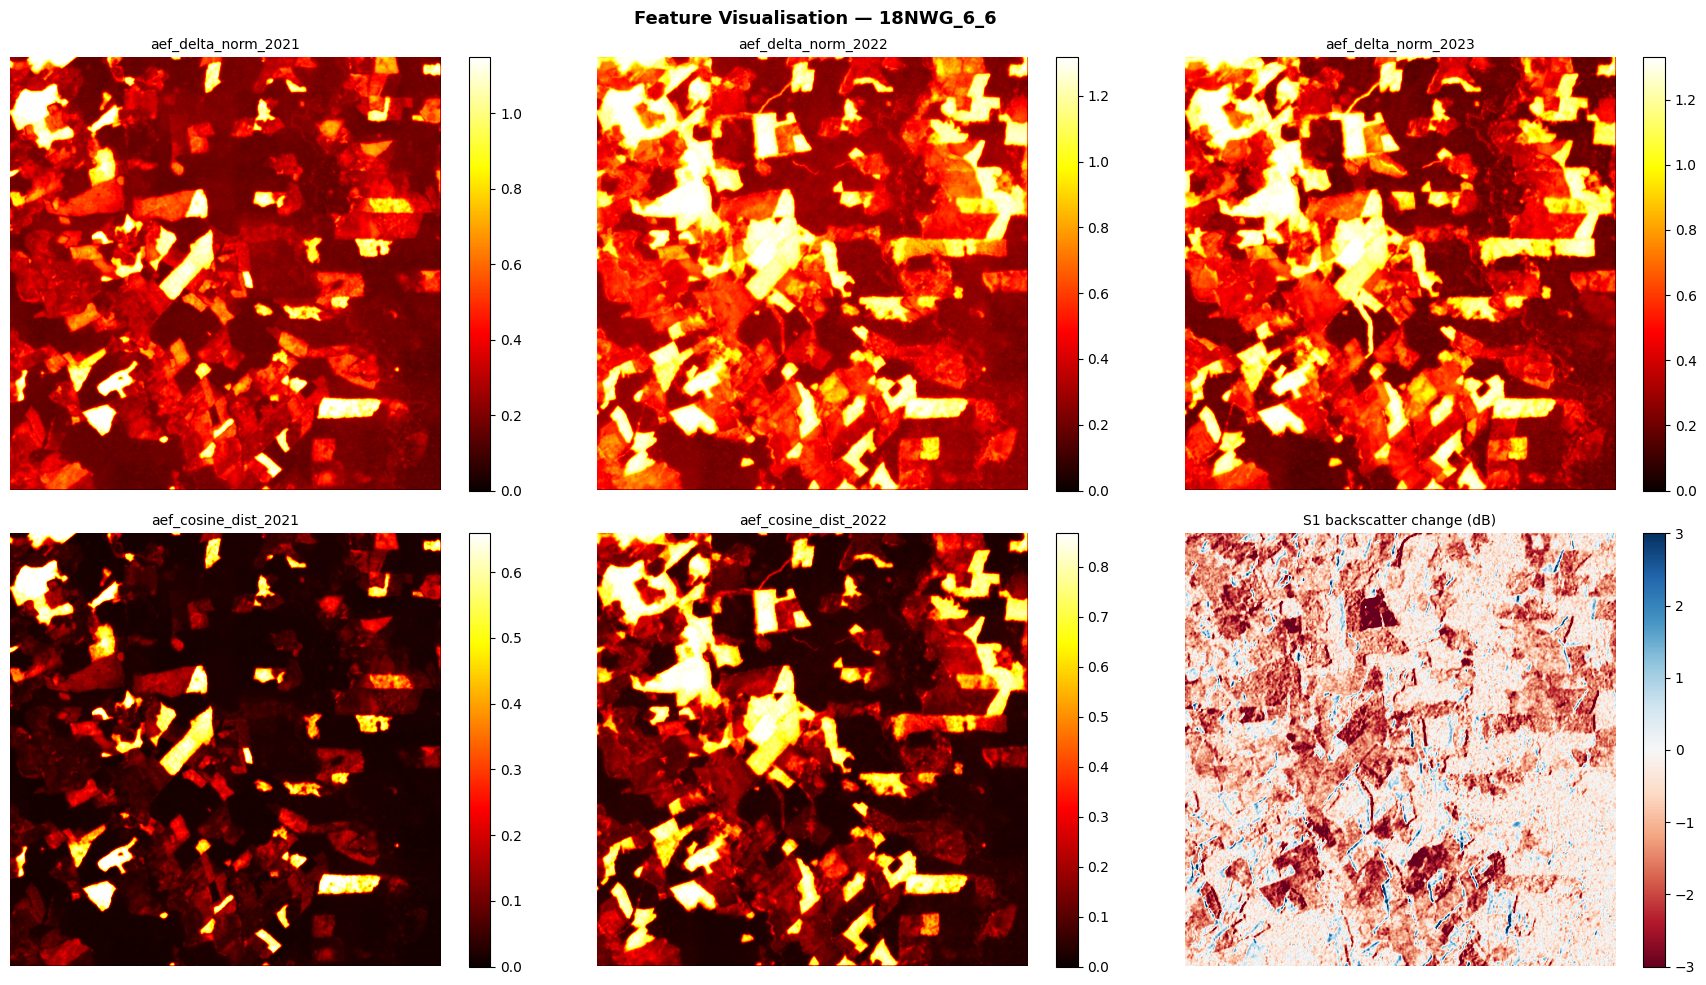

In [6]:
import matplotlib.pyplot as plt

# Load the features we just saved
TILE = train_tiles[0]
with rasterio.open(OUT_DIR / "train" / f"{TILE}_features.tif") as src:
    all_bands = src.read()
    descriptions = list(src.descriptions)

# Find the delta norm and cosine distance bands
norm_bands = {d: all_bands[i] for i, d in enumerate(descriptions) if d and "delta_norm" in d}
cos_bands = {d: all_bands[i] for i, d in enumerate(descriptions) if d and "cosine_dist" in d}
s1_idx = next(i for i, d in enumerate(descriptions) if d and d == "s1_change_mean")
s1_change = all_bands[s1_idx]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot delta norms for each year
for idx, (name, data) in enumerate(list(norm_bands.items())[:3]):
    ax = axes[0, idx]
    valid = data.copy()
    valid[~np.isfinite(valid)] = 0
    im = ax.imshow(valid, cmap="hot", vmin=0, vmax=np.nanpercentile(data, 99))
    ax.set_title(name, fontsize=10)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)

# Plot cosine distances
for idx, (name, data) in enumerate(list(cos_bands.items())[:2]):
    ax = axes[1, idx]
    valid = data.copy()
    valid[~np.isfinite(valid)] = 0
    im = ax.imshow(valid, cmap="hot", vmin=0, vmax=np.nanpercentile(data, 99))
    ax.set_title(name, fontsize=10)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)

# S1 change
ax = axes[1, 2]
valid = s1_change.copy()
valid[~np.isfinite(valid)] = 0
im = ax.imshow(valid, cmap="RdBu", vmin=-3, vmax=3)
ax.set_title("S1 backscatter change (dB)", fontsize=10)
ax.axis("off")
plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle(f"Feature Visualisation — {TILE}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

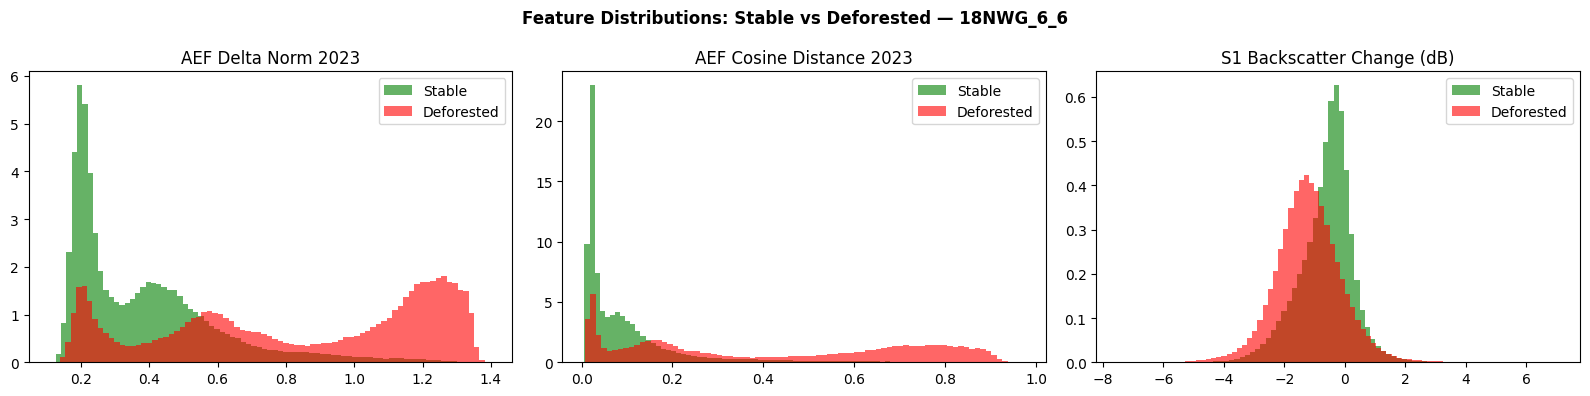

In [8]:
# Overlay with RADD labels to check signal vs deforestation
from rasterio.warp import reproject, Resampling

LABEL_BASE = _ROOT / "data/concept_data/labels/train"
radd_path = LABEL_BASE / "radd" / f"radd_{TILE}_labels.tif"

with rasterio.open(OUT_DIR / "train" / f"{TILE}_features.tif") as feat_src:
    feat_transform = feat_src.transform
    feat_crs = feat_src.crs
    feat_shape = (feat_src.height, feat_src.width)

# Reproject RADD to feature grid
radd_on_feat = np.zeros(feat_shape, dtype=np.int32)
with rasterio.open(radd_path) as src:
    reproject(
        source=src.read(1).astype(np.int32),
        destination=radd_on_feat,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=feat_transform,
        dst_crs=feat_crs,
        resampling=Resampling.nearest,
    )

defor_mask = radd_on_feat > 0
stable_mask = radd_on_feat == 0

# Compare feature distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Delta norm 2023
dn_2023 = norm_bands.get("aef_delta_norm_2023", norm_bands[list(norm_bands.keys())[-1]])
axes[0].hist(dn_2023[stable_mask & np.isfinite(dn_2023)].ravel(), bins=80, alpha=0.6, color="green", label="Stable", density=True)
axes[0].hist(dn_2023[defor_mask & np.isfinite(dn_2023)].ravel(), bins=80, alpha=0.6, color="red", label="Deforested", density=True)
axes[0].set_title("AEF Delta Norm 2023")
axes[0].legend()

# Cosine dist 2023
cd_2023 = cos_bands.get("aef_cosine_dist_2023", cos_bands[list(cos_bands.keys())[-1]])
axes[1].hist(cd_2023[stable_mask & np.isfinite(cd_2023)].ravel(), bins=80, alpha=0.6, color="green", label="Stable", density=True)
axes[1].hist(cd_2023[defor_mask & np.isfinite(cd_2023)].ravel(), bins=80, alpha=0.6, color="red", label="Deforested", density=True)
axes[1].set_title("AEF Cosine Distance 2023")
axes[1].legend()

# S1 change
axes[2].hist(s1_change[stable_mask & np.isfinite(s1_change)].ravel(), bins=80, alpha=0.6, color="green", label="Stable", density=True)
axes[2].hist(s1_change[defor_mask & np.isfinite(s1_change)].ravel(), bins=80, alpha=0.6, color="red", label="Deforested", density=True)
axes[2].set_title("S1 Backscatter Change (dB)")
axes[2].legend()

plt.suptitle(f"Feature Distributions: Stable vs Deforested — {TILE}", fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Process All Tiles

In [9]:
# Process all train tiles
print("=" * 60)
print("PROCESSING ALL TRAIN TILES")
print("=" * 60)

for tile_id in tqdm(train_tiles, desc="Train tiles"):
    try:
        save_tile_features(tile_id, "train")
    except Exception as e:
        print(f"  ERROR on {tile_id}: {e}")

print("\n" + "=" * 60)
print("PROCESSING ALL TEST TILES")
print("=" * 60)

for tile_id in tqdm(test_tiles, desc="Test tiles"):
    try:
        save_tile_features(tile_id, "test")
    except Exception as e:
        print(f"  ERROR on {tile_id}: {e}")

# Summary
import os
for split in ["train", "test"]:
    split_dir = OUT_DIR / split
    if split_dir.exists():
        files = list(split_dir.glob("*.tif"))
        total_mb = sum(f.stat().st_size for f in files) / 1024 / 1024
        print(f"\n{split}: {len(files)} feature files, {total_mb:.0f} MB total")

PROCESSING ALL TRAIN TILES


Train tiles:   0%|          | 0/5 [00:00<?, ?it/s]


Processing: 18NWG_6_6 (train)
  Computing AEF delta features...
  Computing S1 temporal features...
  Saved: /Users/farhanhassan/makeathon-challenge-2026/data/cleaned/features/train/18NWG_6_6_features.tif (400 bands, 1529.0 MB)
  Band summary: 400 bands = 64 baseline + 5×64 deltas + 5 norms + 5 cosine + 6 S1

Processing: 18NWH_1_4 (train)
  Computing AEF delta features...
  Computing S1 temporal features...
  Saved: /Users/farhanhassan/makeathon-challenge-2026/data/cleaned/features/train/18NWH_1_4_features.tif (400 bands, 1530.5 MB)
  Band summary: 400 bands = 64 baseline + 5×64 deltas + 5 norms + 5 cosine + 6 S1

Processing: 18NWJ_8_9 (train)
  Computing AEF delta features...
  Computing S1 temporal features...
  Saved: /Users/farhanhassan/makeathon-challenge-2026/data/cleaned/features/train/18NWJ_8_9_features.tif (400 bands, 1530.5 MB)
  Band summary: 400 bands = 64 baseline + 5×64 deltas + 5 norms + 5 cosine + 6 S1

Processing: 18NWM_9_4 (train)
  Computing AEF delta features...
  

Test tiles:   0%|          | 0/5 [00:00<?, ?it/s]


Processing: 18NVJ_1_6 (test)
  Computing AEF delta features...
  Computing S1 temporal features...
  Saved: /Users/farhanhassan/makeathon-challenge-2026/data/cleaned/features/test/18NVJ_1_6_features.tif (400 bands, 1530.5 MB)
  Band summary: 400 bands = 64 baseline + 5×64 deltas + 5 norms + 5 cosine + 6 S1

Processing: 18NYH_2_1 (test)
  Computing AEF delta features...
  Computing S1 temporal features...
  Saved: /Users/farhanhassan/makeathon-challenge-2026/data/cleaned/features/test/18NYH_2_1_features.tif (400 bands, 1533.6 MB)
  Band summary: 400 bands = 64 baseline + 5×64 deltas + 5 norms + 5 cosine + 6 S1

Processing: 33NTE_5_1 (test)
  Computing AEF delta features...
  Computing S1 temporal features...
  Saved: /Users/farhanhassan/makeathon-challenge-2026/data/cleaned/features/test/33NTE_5_1_features.tif (400 bands, 1538.2 MB)
  Band summary: 400 bands = 64 baseline + 5×64 deltas + 5 norms + 5 cosine + 6 S1

Processing: 47QMA_6_2 (test)
  Computing AEF delta features...
  Computi